In [ ]:
# Car Price Prediction using Machine Learning
# Data Science Internship Task 3
# Sujal Maurya

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [56]:
df = pd.read_csv("car_data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [57]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:")
for col in df.columns:
    print("-", col)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())

DATASET OVERVIEW
Number of Rows    : 301
Number of Columns : 9

Column Names:
- Car_Name
- Year
- Selling_Price
- Present_Price
- Driven_kms
- Fuel_Type
- Selling_type
- Transmission
- Owner

Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

First 5 Records:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [58]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate Records: 2

Dataset Shape After Removing Duplicates:
(299, 9)

Missing Values After Cleaning:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [59]:
print("STATISTICAL SUMMARY")
print("="*50)

display(df.describe())

print("\nAverage Selling Price:",
      round(df['Selling_Price'].mean(),2))

print("\nMaximum Selling Price:",
      round(df['Selling_Price'].max(),2))

print("\nMinimum Selling Price:",
      round(df['Selling_Price'].min(),2))

STATISTICAL SUMMARY


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000



Average Selling Price: 4.59

Maximum Selling Price: 35.0

Minimum Selling Price: 0.1


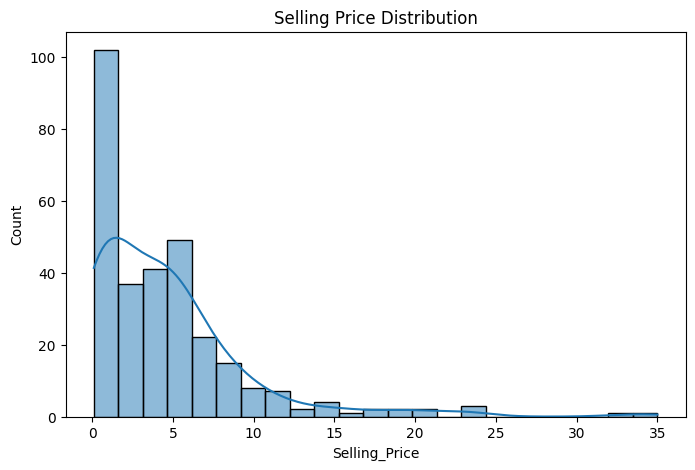

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Selling_Price'],
    kde=True
)

plt.title("Selling Price Distribution")
plt.show()

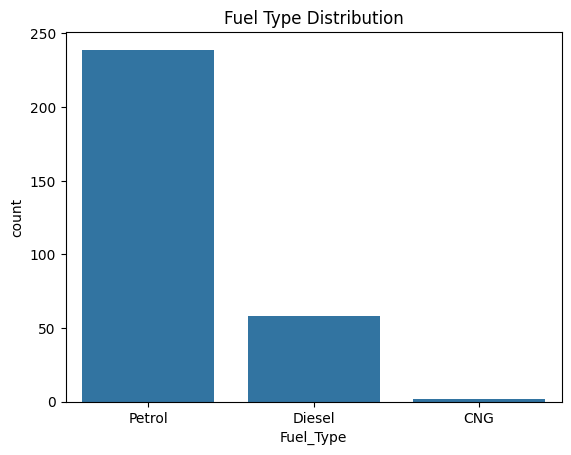

In [ ]:
sns.countplot(
    x='Fuel_Type',
    data=df
)

plt.title("Fuel Type Distribution")
plt.show()

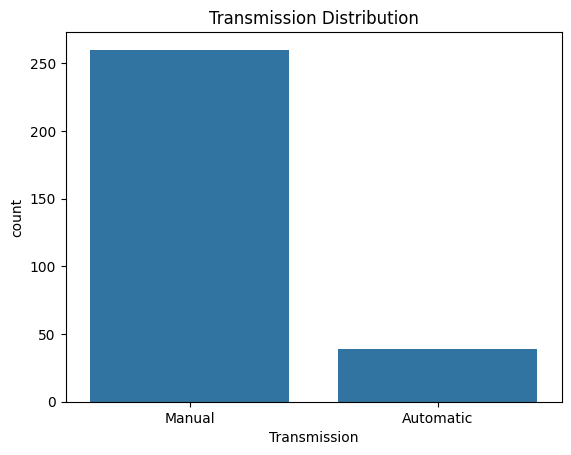

In [ ]:
sns.countplot(
    x='Transmission',
    data=df
)

plt.title("Transmission Distribution")
plt.show()

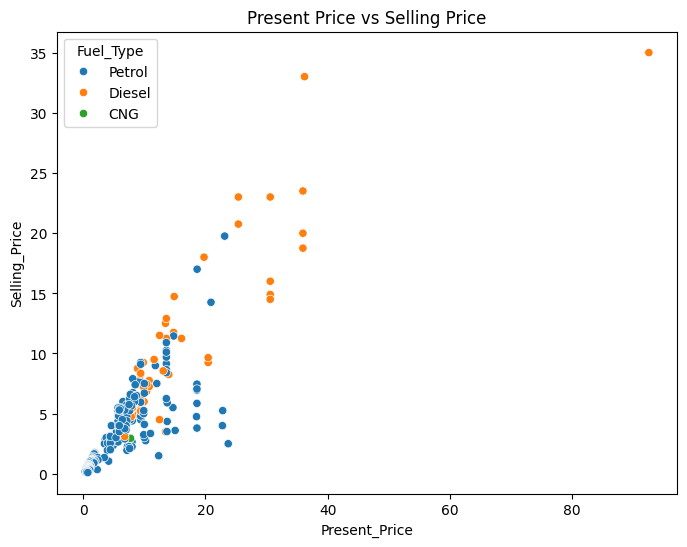

In [60]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Present_Price',
    y='Selling_Price',
    hue='Fuel_Type'
)

plt.title("Present Price vs Selling Price")
plt.show()

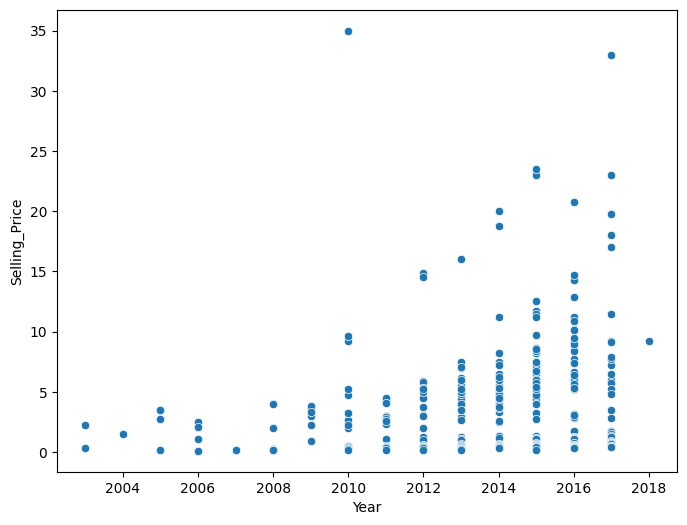

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Year',
    y='Selling_Price'
)

plt.show()

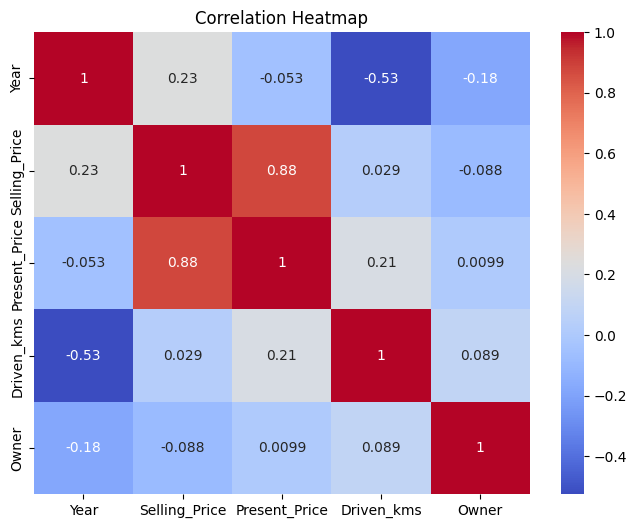

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [62]:
current_year = 2025

df['Car_Age'] = current_year - df['Year']

print("Car Age Feature Created Successfully")

display(
    df[['Year','Car_Age']].head()
)

Car Age Feature Created Successfully


,Year,Car_Age
0,2014,11
1,2013,12
2,2017,8
3,2011,14
4,2014,11


In [49]:
import pandas as pd

df = pd.read_csv("car_data.csv")

print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [50]:
df.drop(
    ['Car_Name','Year'],
    axis=1,
    inplace=True
)

In [63]:
categorical_cols = [
    'Fuel_Type',
    'Selling_type',
    'Transmission'
]

print("Categorical Columns:")
print(categorical_cols)

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("\nEncoding Completed Successfully")

display(df.head())

Categorical Columns:
['Fuel_Type', 'Selling_type', 'Transmission']

Encoding Completed Successfully


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,11,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,12,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,8,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,14,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,11,True,False,False,True


In [64]:
print("="*50)
print("FINAL DATASET READY FOR MACHINE LEARNING")
print("="*50)

print("Shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print("-", col)

display(df.head())

FINAL DATASET READY FOR MACHINE LEARNING
Shape: (299, 11)

Columns:
- Car_Name
- Year
- Selling_Price
- Present_Price
- Driven_kms
- Owner
- Car_Age
- Fuel_Type_Diesel
- Fuel_Type_Petrol
- Selling_type_Individual
- Transmission_Manual


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,11,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,12,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,8,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,14,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,11,True,False,False,True


In [52]:
X = df.drop(
    'Selling_Price',
    axis=1
)

y = df['Selling_Price']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [40]:
predictions = model.predict(
    X_test
)

In [65]:
print("Model Evaluation")
print("="*50)

print(
    "Mean Absolute Error (MAE):",
    round(mean_absolute_error(y_test,predictions),2)
)

print(
    "Mean Squared Error (MSE):",
    round(mean_squared_error(y_test,predictions),2)
)

print(
    "R2 Score:",
    round(r2_score(y_test,predictions),4)
)

Model Evaluation
Mean Absolute Error (MAE): 0.64
Mean Squared Error (MSE): 0.93
R2 Score: 0.9595


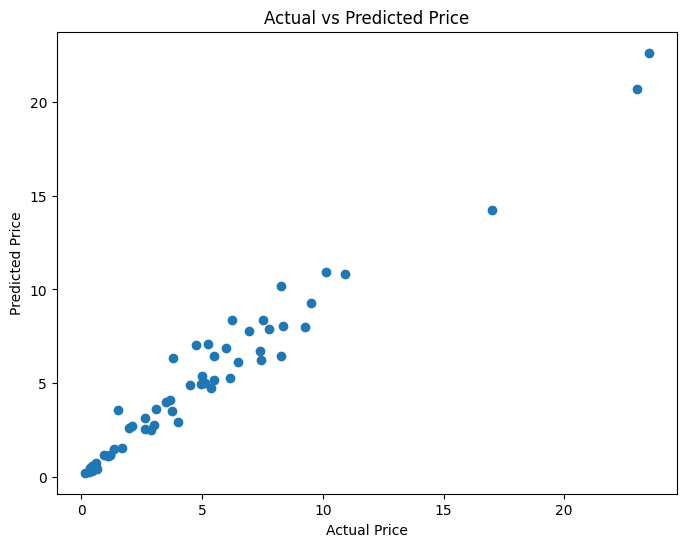

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Price"
)

plt.show()

In [66]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
)

,0
Present_Price,0.885749
Driven_kms,0.084973
Transmission_Manual,0.013947
Fuel_Type_Petrol,0.005706
Fuel_Type_Diesel,0.004920
Selling_type_Individual,0.002918
Owner,0.001789


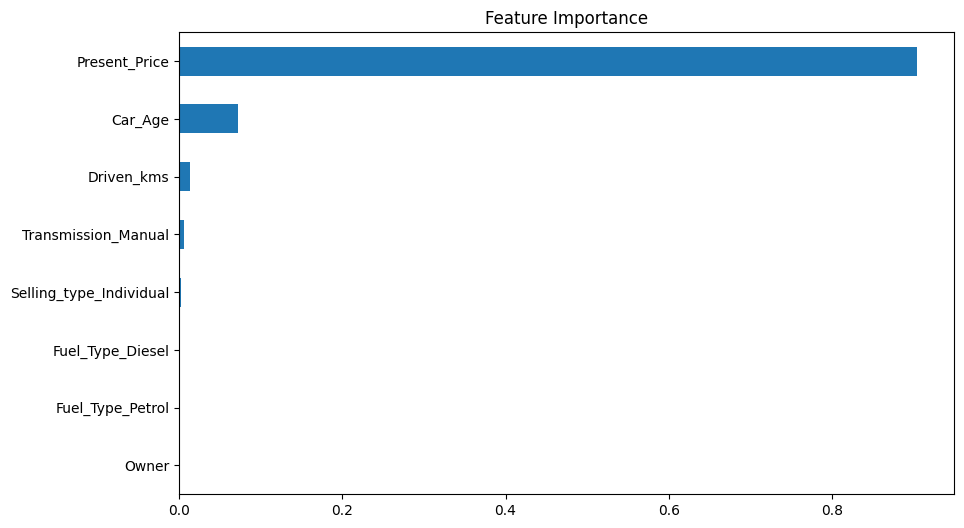

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.show()

In [ ]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print(
    "Predicted Price:",
    prediction[0]
)

Predicted Price: 3.581500000000002


In [ ]:
print("""
Conclusion

1. Car price data was successfully analyzed.

2. Various visualizations were used to understand
   relationships between features and selling price.

3. Feature engineering was performed by creating
   a Car Age feature.

4. Categorical variables were converted into
   numerical format.

5. A Random Forest Regressor was trained to
   predict car selling prices.

6. The model achieved good prediction performance
   and identified the most influential features
   affecting car prices.

7. This project demonstrates the use of machine
   learning for real-world price prediction problems.
""")


Conclusion

1. Car price data was successfully analyzed.

2. Various visualizations were used to understand
   relationships between features and selling price.

3. Feature engineering was performed by creating
   a Car Age feature.

4. Categorical variables were converted into
   numerical format.

5. A Random Forest Regressor was trained to
   predict car selling prices.

6. The model achieved good prediction performance
   and identified the most influential features
   affecting car prices.

7. This project demonstrates the use of machine
   learning for real-world price prediction problems.

